In [1]:
# ==========================================
# Lesson 23 - Model Evaluation Metrics
# ==========================================

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

ee.Initialize(project="oc-flux")

Map = geemap.Map()

point = ee.Geometry.Point([77.2090,28.6139])

collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(point)
    .filterDate("2023-01-01","2023-12-31")
)

image = collection.median()

Map.centerObject(point,10)

Map

Map(center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'], posit…

In [ ]:
Example Dataset

In [2]:
observed = np.array([
    2,
    3,
    5,
    7,
    9
])

predicted = np.array([
    2.2,
    2.8,
    4.9,
    7.4,
    8.5
])

In [ ]:
R² (Coefficient of Determination)

This is the most common metric in research papers.
Meaning :

The model explains about 99% of the variability in the observed POC values.

In [3]:
r2 = r2_score(
    observed,
    predicted
)

print("R² =",r2)

R² = 0.9847560975609756


In [ ]:
Mean Absolute Error (MAE)

MAE is simply the average absolute error.
On average, predictions differ from observations by 0.28 mg/L.

In [4]:
mae = mean_absolute_error(
    observed,
    predicted
)

print(mae)

0.2800000000000001


In [ ]:
Mean Squared Error (MSE)

Instead of taking the absolute error, MSE squares the errors.
Large errors receive much greater penalties.

In [5]:
mse = mean_squared_error(
    observed,
    predicted
)

print(mse)

0.10000000000000006


In [ ]:
Root Mean Square Error (RMSE)

RMSE is simply:

√MSE

RMSE is easier to interpret because it has the same units as POC (mg/L).

In [6]:
rmse = np.sqrt(
    mean_squared_error(
        observed,
        predicted
    )
)

print(rmse)

0.31622776601683805


In [ ]:
Complete Example

In [7]:
from sklearn.metrics import *

print("R²")

print(
    r2_score(
        observed,
        predicted
    )
)

print()

print("MAE")

print(
    mean_absolute_error(
        observed,
        predicted
    )
)

print()

print("RMSE")

print(
    np.sqrt(
        mean_squared_error(
            observed,
            predicted
        )
    )
)

R²
0.9847560975609756

MAE
0.2800000000000001

RMSE
0.31622776601683805


In [ ]:
Scatter Plot

Researchers almost always include a scatter plot.

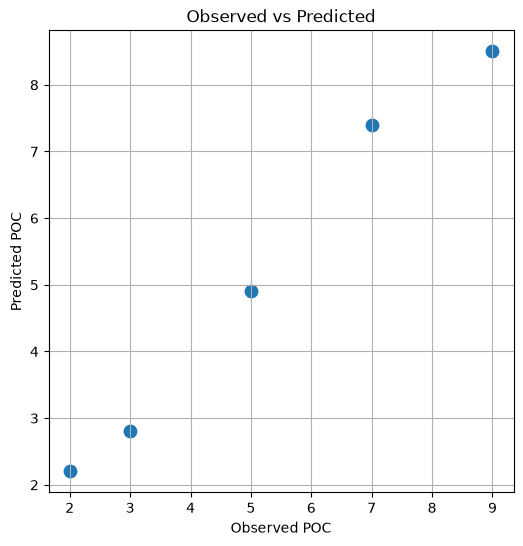

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(
    observed,
    predicted,
    s=80
)

plt.xlabel("Observed POC")

plt.ylabel("Predicted POC")

plt.title("Observed vs Predicted")

plt.grid()

plt.show()

In [ ]:
Perfect Model Line

Now add the 1:1 line.

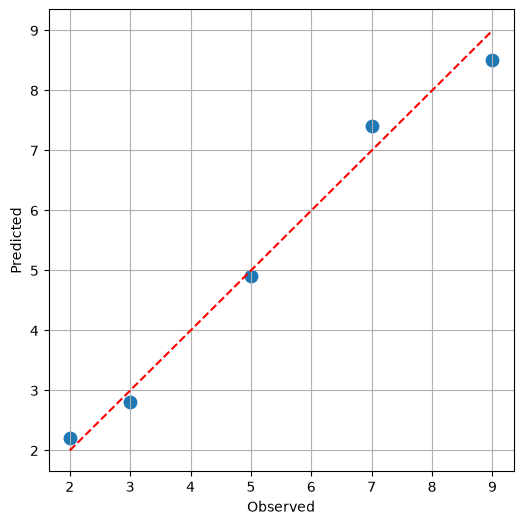

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(
    observed,
    predicted,
    s=80
)

plt.plot(
    [2,9],
    [2,9],
    "r--"
)

plt.xlabel("Observed")

plt.ylabel("Predicted")

plt.grid()

plt.show()

In [ ]:
Complete Evaluation Function

In [10]:
def evaluate(observed,predicted):

    print("R²")

    print(r2_score(observed,predicted))

    print()

    print("MAE")

    print(mean_absolute_error(observed,predicted))

    print()

    print("RMSE")

    print(
        np.sqrt(
            mean_squared_error(
                observed,
                predicted
            )
        )
    )

evaluate(
    observed,
    predicted
)

R²
0.9847560975609756

MAE
0.2800000000000001

RMSE
0.31622776601683805
